In [1]:
import sys, os

if not os.path.isdir("src"):
    project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
    os.chdir(project_root)

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory:", os.getcwd())

Working directory: c:\DLAssignment\Deep-Learning-Assignment-SE4050


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.data_contract import load_har_npz
from src.models.cnn import load_cnn_model

data = load_har_npz("data/uci_har_processed.npz")
X_val, y_val = data["X_val"], data["y_val"]

model = load_cnn_model("outputs/cnn/run_20260927_123513/best_model.keras")

# Get predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Validation accuracy:", (y_pred == y_val).mean())

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Validation accuracy: 0.9042857142857142


In [3]:
activity_names = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

SITTING = 3
STANDING = 4

# Find windows where the true label was SITTING or STANDING, but the model got it wrong
sitting_as_standing = np.where((y_val == SITTING) & (y_pred == STANDING))[0]
standing_as_sitting = np.where((y_val == STANDING) & (y_pred == SITTING))[0]

print(f"SITTING misclassified as STANDING: {len(sitting_as_standing)} windows")
print(f"STANDING misclassified as SITTING: {len(standing_as_sitting)} windows")

# For context: total errors overall
total_errors = (y_pred != y_val).sum()
print(f"\nTotal validation errors: {total_errors}")
print(f"Sitting/Standing confusion accounts for: {len(sitting_as_standing) + len(standing_as_sitting)} of those ({100*(len(sitting_as_standing)+len(standing_as_sitting))/total_errors:.1f}%)")

SITTING misclassified as STANDING: 43 windows
STANDING misclassified as SITTING: 60 windows

Total validation errors: 134
Sitting/Standing confusion accounts for: 103 of those (76.9%)


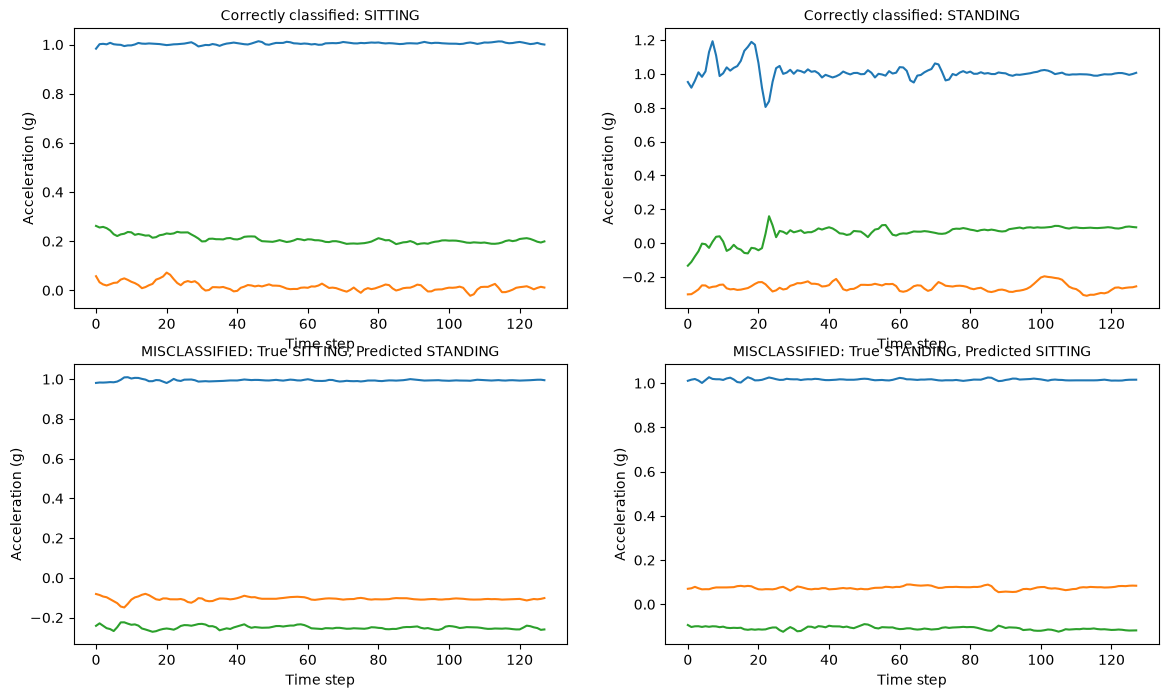

In [4]:
# Load raw (unnormalized) validation data for physically meaningful plots
from src.data.uci_har_loader import build_processed_dataset

raw = build_processed_dataset(standardize=False)
X_val_raw = raw["X_val"]

# Pick one example of each: a correct SITTING, a correct STANDING, 
# and one misclassified window from each confusion direction
correct_sitting_idx = np.where((y_val == SITTING) & (y_pred == SITTING))[0][0]
correct_standing_idx = np.where((y_val == STANDING) & (y_pred == STANDING))[0][0]
wrong_sitting_idx = sitting_as_standing[0]   # true SITTING, predicted STANDING
wrong_standing_idx = standing_as_sitting[0]  # true STANDING, predicted SITTING

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

examples = [
    (correct_sitting_idx, "Correctly classified: SITTING", axes[0, 0]),
    (correct_standing_idx, "Correctly classified: STANDING", axes[0, 1]),
    (wrong_sitting_idx, "MISCLASSIFIED: True SITTING, Predicted STANDING", axes[1, 0]),
    (wrong_standing_idx, "MISCLASSIFIED: True STANDING, Predicted SITTING", axes[1, 1]),
]

for idx, title, ax in examples:
    window = X_val_raw[idx]
    ax.plot(window[:, 6], label="acc_x")
    ax.plot(window[:, 7], label="acc_y")
    ax.plot(window[:, 8], label="acc_z")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Acceleration (g)")

## Error Analysis: SITTING vs STANDING Confusion

Of 134 total validation errors, 103 (76.9%) were SITTING↔STANDING confusions, 
making this by far the dominant failure mode of the CNN.

The raw signal comparison reveals why: `acc_x` is nearly identical across all four 
examples (~1.0g), meaning it carries little discriminative information — both postures 
hold the phone in roughly the same primary orientation relative to gravity. The real 
distinguishing signal lives in the smaller `acc_y` and `acc_z` components, where 
correctly classified SITTING and STANDING windows show modestly different values.

The misclassified examples fall into an ambiguous zone between the two classes' typical 
ranges, or in one case (SITTING→STANDING) even beyond STANDING's typical acc_z range 
entirely — suggesting genuine sensor-level ambiguity, likely caused by how the phone 
was carried or the exact body angle during that specific window, rather than a flaw in 
the model's learned features.

This is a physical, not algorithmic, limitation: a single waist-mounted accelerometer 
simply cannot always distinguish "sitting upright" from "standing upright," since both 
involve the torso being vertical with the phone in a similar orientation. This finding 
is consistent across our EDA (raw signal plots and t-SNE clustering both predicted 
this exact confusion before we ever trained a model), giving strong triangulated 
evidence for §8's discussion of model limitations.